In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Create aproject folder

In [4]:
PROJECT_DIR = "/content/drive/MyDrive/HealthPulse_AI"


make subfolder

In [5]:
import os

SUBS = [
    f"{PROJECT_DIR}",
    f"{PROJECT_DIR}/data",
    f"{PROJECT_DIR}/data/raw",
    f"{PROJECT_DIR}/notebooks"
]
for p in SUBS:
    os.makedirs(p, exist_ok=True)

PROJECT_DIR


'/content/drive/MyDrive/HealthPulse_AI'

Install and import libraries

In [6]:
!pip install requests pandas
import requests
import pandas as pd
import os


SERPAPI KEY


In [7]:
API_KEY ="c982fb4d8b3c56a7bbbd36a74b1c4e8ea9522423ee67b2f36681c4cbaeac222b"

Add Hospital DATA IDs

In [8]:
HOSPITALS = {
    "Aster_Hospital_Mankhool": "0x3e5f43174b4f3f4d:0x3f6dfab2d5b9b241",
    "Mediclinic_City_Hospital": "0x3e5f5d362ab15a01:0x386df9280945ffe2",
    "Thumbay_Hospital_Ajman": "0x3e5f5844c7671401:0x56623dd6ff32e8e9"
}

Scraping Code

Get the hospital Id's

In [9]:
import requests

def get_place_data_id(place_query, api_key):
    params = {
        "engine": "google_maps",
        "q": place_query,
        "type": "search",
        "api_key": api_key
    }
    data = requests.get("https://serpapi.com/search.json", params=params).json()

    # First try local results
    if "local_results" in data:
        for item in data["local_results"]:
            if "data_id" in item:
                return item["data_id"]

    # Try place_results
    if "place_results" in data and "data_id" in data["place_results"]:
        return data["place_results"]["data_id"]

    return None


hospitals_to_search = [
    "Aster Hospital Mankhool Dubai",
    "Mediclinic City Hospital Dubai",
    "Thumbay Hospital Ajman"
]

for name in hospitals_to_search:
    did = get_place_data_id(name, API_KEY)
    print(name, "→", did)


Aster Hospital Mankhool Dubai → 0x3e5f43174b4f3f4d:0x3f6dfab2d5b9b241
Mediclinic City Hospital Dubai → 0x3e5f5d362ab15a01:0x386df9280945ffe2
Thumbay Hospital Ajman → 0x3e5f5844c7671401:0x56623dd6ff32e8e9


Run the activator

In [10]:
def activate_reviews(data_id):
    params = {
        "engine": "google_maps",
        "data_id": data_id,
        "api_key": API_KEY
    }
    requests.get("https://serpapi.com/search.json", params=params)

for name, did in HOSPITALS.items():
    print("Activating:", name)
    activate_reviews(did)


Activating: Aster_Hospital_Mankhool
Activating: Mediclinic_City_Hospital
Activating: Thumbay_Hospital_Ajman


Now run the 100-review scraper

In [11]:
import time
import pandas as pd
import requests

def fetch_reviews_multiple_pages(data_id, api_key, max_reviews=100):
    all_reviews = []
    next_page_token = None

    while True:
        params = {
            "engine": "google_maps_reviews",
            "data_id": data_id,
            "api_key": api_key
        }

        if next_page_token:
            params["next_page_token"] = next_page_token

        resp = requests.get("https://serpapi.com/search.json", params=params).json()
        reviews = resp.get("reviews", [])
        all_reviews.extend(reviews)

        print("Fetched:", len(all_reviews))

        if len(all_reviews) >= max_reviews:
            break

        next_page_token = resp.get("serpapi_pagination", {}).get("next_page_token")

        if not next_page_token:
            break

        time.sleep(2)

    return all_reviews[:max_reviews]


all_rows = []

for hospital_name, data_id in HOSPITALS.items():
    print(f"\nFetching: {hospital_name}")
    reviews = fetch_reviews_multiple_pages(data_id, API_KEY, max_reviews=100)

    for r in reviews:
        all_rows.append({
            "hospital": hospital_name,
            "rating": r.get("rating"),
            "review_text": r.get("snippet"),
            "datetime": r.get("date"),
        })

df = pd.DataFrame(all_rows)
df.to_csv(f"{PROJECT_DIR}/data/raw/uae_hospital_reviews_300.csv", index=False)

print("\n✅ DONE!")
print("Total reviews:", len(df))



Fetching: Aster_Hospital_Mankhool
Fetched: 8
Fetched: 18
Fetched: 28
Fetched: 38
Fetched: 48
Fetched: 58
Fetched: 68
Fetched: 78
Fetched: 88
Fetched: 98
Fetched: 108

Fetching: Mediclinic_City_Hospital
Fetched: 8
Fetched: 18
Fetched: 28
Fetched: 38
Fetched: 48
Fetched: 58
Fetched: 68
Fetched: 78
Fetched: 88
Fetched: 98
Fetched: 108

Fetching: Thumbay_Hospital_Ajman
Fetched: 8
Fetched: 18
Fetched: 28
Fetched: 38
Fetched: 48
Fetched: 58
Fetched: 68
Fetched: 78
Fetched: 88
Fetched: 98
Fetched: 108

✅ DONE!
Total reviews: 300


Phase 2: Data Cleaning & Preprocessing

Load Data Set

In [12]:
import pandas as pd

# load file
df = pd.read_csv("/content/drive/MyDrive/HealthPulse_AI/data/raw/uae_hospital_reviews_300.csv")
print(df.shape)
df.head()

(300, 4)


,hospital,rating,review_text,datetime
0,Aster_Hospital_Mankhool,5.0,We had an amazing experience at Aster Hospital...,3 months ago
1,Aster_Hospital_Mankhool,5.0,I want to extend my deepest appreciation to al...,Edited 2 months ago
2,Aster_Hospital_Mankhool,5.0,I came back for a reason. Love the services. M...,2 weeks ago
3,Aster_Hospital_Mankhool,5.0,I would like to express my sincere appreciatio...,a month ago
4,Aster_Hospital_Mankhool,5.0,"Good service, neat and clean. Well organised p...",a month ago


Drop missing or duplicate rows

In [13]:
df.dropna(subset=["review_text"], inplace=True)
df.drop_duplicates(subset=["review_text"], inplace=True)
print(df.shape)


(300, 4)


Clean text (remove punctuation, links, special chars, emojis)

In [14]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)      # remove links
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)     # remove punctuation/symbols
    text = re.sub(r"\s+", " ", text)                # remove extra spaces
    return text.strip().lower()

df["cleaned_text"] = df["review_text"].apply(clean_text)
df.head(10)


,hospital,rating,review_text,datetime,cleaned_text
0,Aster_Hospital_Mankhool,5.0,We had an amazing experience at Aster Hospital...,3 months ago,we had an amazing experience at aster hospital...
1,Aster_Hospital_Mankhool,5.0,I want to extend my deepest appreciation to al...,Edited 2 months ago,i want to extend my deepest appreciation to al...
2,Aster_Hospital_Mankhool,5.0,I came back for a reason. Love the services. M...,2 weeks ago,i came back for a reason love the services mad...
3,Aster_Hospital_Mankhool,5.0,I would like to express my sincere appreciatio...,a month ago,i would like to express my sincere appreciatio...
4,Aster_Hospital_Mankhool,5.0,"Good service, neat and clean. Well organised p...",a month ago,good service neat and clean well organised pro...
5,Aster_Hospital_Mankhool,5.0,"It was a good experience, where the staffs do ...",Edited a month ago,it was a good experience where the staffs do n...
6,Aster_Hospital_Mankhool,5.0,Excellent care and professional staff!\nI had ...,2 weeks ago,excellent care and professional staff i had a ...
7,Aster_Hospital_Mankhool,5.0,I would like to express my heartfelt appreciat...,4 weeks ago,i would like to express my heartfelt appreciat...
8,Aster_Hospital_Mankhool,5.0,I had such a pleasant experience with Dr Sneha...,a week ago,i had such a pleasant experience with dr sneha...
9,Aster_Hospital_Mankhool,1.0,Date of Visit: 15 July 2025 - Review of Aster ...,3 months ago,date of visit 15 july 2025 review of aster hos...


Detect Arabic reviews and translate
f some reviews appear in Arabic, use Google Translate API or the deep_translator library.

Install

In [15]:
!pip install deep-translator


Run

automatically converts Arabic → English when needed.

In [16]:
from deep_translator import GoogleTranslator

def translate_to_english(text):
    try:
        return GoogleTranslator(source='auto', target='en').translate(text)
    except:
        return text

df["translated_text"] = df["cleaned_text"].apply(translate_to_english)
df.head()


,hospital,rating,review_text,datetime,cleaned_text,translated_text
0,Aster_Hospital_Mankhool,5.0,We had an amazing experience at Aster Hospital...,3 months ago,we had an amazing experience at aster hospital...,we had an amazing experience at aster hospital...
1,Aster_Hospital_Mankhool,5.0,I want to extend my deepest appreciation to al...,Edited 2 months ago,i want to extend my deepest appreciation to al...,i want to extend my deepest appreciation to al...
2,Aster_Hospital_Mankhool,5.0,I came back for a reason. Love the services. M...,2 weeks ago,i came back for a reason love the services mad...,i came back for a reason love the services mad...
3,Aster_Hospital_Mankhool,5.0,I would like to express my sincere appreciatio...,a month ago,i would like to express my sincere appreciatio...,i would like to express my sincere appreciatio...
4,Aster_Hospital_Mankhool,5.0,"Good service, neat and clean. Well organised p...",a month ago,good service neat and clean well organised pro...,good service neat and clean well organised pro...


Lemmatization (normalize words)

In [17]:
!pip install -U spacy==3.8.0
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 17.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [18]:
!python -m spacy download en_core_web_sm
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df["lemmatized_text"] = df["translated_text"].apply(lemmatize_text)
df.head()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


,hospital,rating,review_text,datetime,cleaned_text,translated_text,lemmatized_text
0,Aster_Hospital_Mankhool,5.0,We had an amazing experience at Aster Hospital...,3 months ago,we had an amazing experience at aster hospital...,we had an amazing experience at aster hospital...,we have an amazing experience at aster hospita...
1,Aster_Hospital_Mankhool,5.0,I want to extend my deepest appreciation to al...,Edited 2 months ago,i want to extend my deepest appreciation to al...,i want to extend my deepest appreciation to al...,I want to extend my deep appreciation to all t...
2,Aster_Hospital_Mankhool,5.0,I came back for a reason. Love the services. M...,2 weeks ago,i came back for a reason love the services mad...,i came back for a reason love the services mad...,I come back for a reason love the service mada...
3,Aster_Hospital_Mankhool,5.0,I would like to express my sincere appreciatio...,a month ago,i would like to express my sincere appreciatio...,i would like to express my sincere appreciatio...,I would like to express my sincere appreciatio...
4,Aster_Hospital_Mankhool,5.0,"Good service, neat and clean. Well organised p...",a month ago,good service neat and clean well organised pro...,good service neat and clean well organised pro...,good service neat and clean well organise proc...


In [19]:
## testing
import spacy
nlp = spacy.load("en_core_web_sm")

text = "Doctors were amazing and the service was very good!"
doc = nlp(text)
print([token.lemma_ for token in doc])


['doctor', 'be', 'amazing', 'and', 'the', 'service', 'be', 'very', 'good', '!']


Save cleaned dataset

In [20]:
clean_path = "/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_cleaned.csv"
df.to_csv(clean_path, index=False)
print("✅ Cleaned data saved at:", clean_path)

✅ Cleaned data saved at: /content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_cleaned.csv


# Sentiment Analysis
use Hugging Face’s transformers library and a pre-trained model (DistilBERT) to classify review sentiment automatically.

Install and Import Required Libraries

In [21]:
!pip install transformers torch


In [22]:
from transformers import pipeline
import pandas as pd


Load Cleaned Dataset

In [23]:
df = pd.read_csv("/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_cleaned.csv")
print(df.shape)
df.head()


(300, 7)


,hospital,rating,review_text,datetime,cleaned_text,translated_text,lemmatized_text
0,Aster_Hospital_Mankhool,5.0,We had an amazing experience at Aster Hospital...,3 months ago,we had an amazing experience at aster hospital...,we had an amazing experience at aster hospital...,we have an amazing experience at aster hospita...
1,Aster_Hospital_Mankhool,5.0,I want to extend my deepest appreciation to al...,Edited 2 months ago,i want to extend my deepest appreciation to al...,i want to extend my deepest appreciation to al...,I want to extend my deep appreciation to all t...
2,Aster_Hospital_Mankhool,5.0,I came back for a reason. Love the services. M...,2 weeks ago,i came back for a reason love the services mad...,i came back for a reason love the services mad...,I come back for a reason love the service mada...
3,Aster_Hospital_Mankhool,5.0,I would like to express my sincere appreciatio...,a month ago,i would like to express my sincere appreciatio...,i would like to express my sincere appreciatio...,I would like to express my sincere appreciatio...
4,Aster_Hospital_Mankhool,5.0,"Good service, neat and clean. Well organised p...",a month ago,good service neat and clean well organised pro...,good service neat and clean well organised pro...,good service neat and clean well organise proc...


**Load the Sentiment Analysis Model**

Why we use DistilBERT for Sentiment Analysis
DistilBERT is a lightweight version of BERT (a powerful Transformer model) that understands the context and meaning of words in sentences.

It’s pre-trained on millions of text examples and fine-tuned for sentiment analysis,so it can accurately classify each hospital review as POSITIVE or NEGATIVE.

We use this model because it is fast, accurate, and ideal for short texts like patient reviews.


In [24]:
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


**Run the Model on Your Reviews**

Analyze the text and store results in two new columns:

Sentiment_Label

Sentiment_Score

In [25]:
def analyze_sentiment(text):
    try:
        result = sentiment_analyzer(text[:512])[0]  # limit to 512 tokens per review
        return result['label'], result['score']
    except:
        return None, None

df[['Sentiment_Label', 'Sentiment_Score']] = df['lemmatized_text'].apply(
    lambda x: pd.Series(analyze_sentiment(str(x)))
)


**Preview Results**

In [26]:
df[['hospital', 'lemmatized_text', 'Sentiment_Label', 'Sentiment_Score']].head(10)


,hospital,lemmatized_text,Sentiment_Label,Sentiment_Score
0,Aster_Hospital_Mankhool,we have an amazing experience at aster hospita...,POSITIVE,0.998393
1,Aster_Hospital_Mankhool,I want to extend my deep appreciation to all t...,POSITIVE,0.999705
2,Aster_Hospital_Mankhool,I come back for a reason love the service mada...,POSITIVE,0.988270
3,Aster_Hospital_Mankhool,I would like to express my sincere appreciatio...,POSITIVE,0.999837
4,Aster_Hospital_Mankhool,good service neat and clean well organise proc...,POSITIVE,0.720603
5,Aster_Hospital_Mankhool,it be a good experience where the staff do not...,POSITIVE,0.993311
6,Aster_Hospital_Mankhool,excellent care and professional staff I have a...,POSITIVE,0.999834
7,Aster_Hospital_Mankhool,I would like to express my heartfelt appreciat...,POSITIVE,0.999849
8,Aster_Hospital_Mankhool,I have such a pleasant experience with dr sneh...,POSITIVE,0.999618
9,Aster_Hospital_Mankhool,date of visit 15 july 2025 review of aster hos...,NEGATIVE,0.992915


**Save Results**

In [27]:
save_path = "/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_sentiment.csv"
df.to_csv(save_path, index=False)
print("✅ Sentiment analysis complete! Saved at:", save_path)


✅ Sentiment analysis complete! Saved at: /content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_sentiment.csv


**Review Model Output**

In [28]:
df['Sentiment_Label'].value_counts()


,count
Sentiment_Label,
POSITIVE,238
NEGATIVE,62


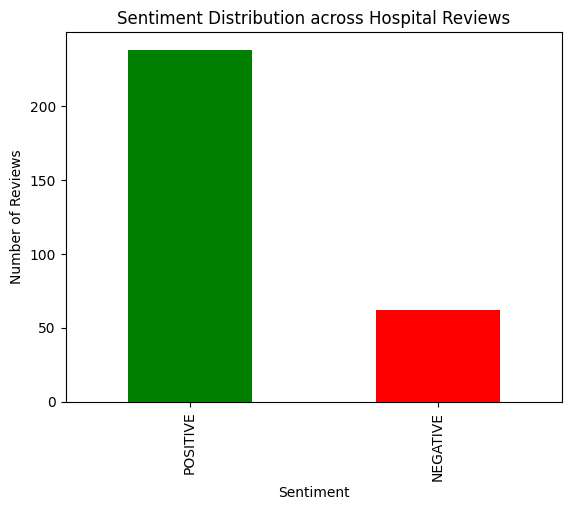

In [29]:
import matplotlib.pyplot as plt

df['Sentiment_Label'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title("Sentiment Distribution across Hospital Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


**Topic Modeling**


Topic Modeling helps to identify what patients are talking about in the hospital reviews.
Examples of topics will discover:

Waiting time

Doctor behavior

Staff attitude

Cleanliness

Billing issues

Emergency services

Reception & front-desk

Pharmacy

Nursing quality

This step shows themes behind patient reviews, not just positive or negative.

**Why Topic Modeling?**

Because sentiment alone doesn’t tell why the review is positive or negative.

Topic modeling answers:



*   What issues do patients complain about?
*   What do they praise the hospital for?
*   What are the top service areas mentioned?


This gives dashboard deeper insights.

***Which Topic Modeling Method Will We Use?***

We will use BERTopic — a modern, powerful topic modeling library.


Why BERTopic?

Works perfectly with short text (like reviews)

Uses transformer embeddings → more accurate

Creates topics + keywords automatically

Easy to visualize

Works smoothly on Google Colab

Install BERTopic and dependencies

In [30]:
!pip install bertopic
!pip install sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 4.0 MB/s eta 0:00:00


**Load sentiment dataset**

In [31]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_sentiment.csv")
df.head()


,hospital,rating,review_text,datetime,cleaned_text,translated_text,lemmatized_text,Sentiment_Label,Sentiment_Score
0,Aster_Hospital_Mankhool,5.0,We had an amazing experience at Aster Hospital...,3 months ago,we had an amazing experience at aster hospital...,we had an amazing experience at aster hospital...,we have an amazing experience at aster hospita...,POSITIVE,0.998393
1,Aster_Hospital_Mankhool,5.0,I want to extend my deepest appreciation to al...,Edited 2 months ago,i want to extend my deepest appreciation to al...,i want to extend my deepest appreciation to al...,I want to extend my deep appreciation to all t...,POSITIVE,0.999705
2,Aster_Hospital_Mankhool,5.0,I came back for a reason. Love the services. M...,2 weeks ago,i came back for a reason love the services mad...,i came back for a reason love the services mad...,I come back for a reason love the service mada...,POSITIVE,0.988270
3,Aster_Hospital_Mankhool,5.0,I would like to express my sincere appreciatio...,a month ago,i would like to express my sincere appreciatio...,i would like to express my sincere appreciatio...,I would like to express my sincere appreciatio...,POSITIVE,0.999837
4,Aster_Hospital_Mankhool,5.0,"Good service, neat and clean. Well organised p...",a month ago,good service neat and clean well organised pro...,good service neat and clean well organised pro...,good service neat and clean well organise proc...,POSITIVE,0.720603


**Load Embedding Model (MiniLM)**

In [32]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Fit BERTopic Model**

In [33]:
from bertopic import BERTopic

topic_model = BERTopic(embedding_model=embedding_model)
topics, probabilities = topic_model.fit_transform(df["cleaned_text"])



/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


**Remove stopwords BEFORE topic modeling**

In [36]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df["no_stopwords"] = df["cleaned_text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)


In [37]:
topics, probabilities = topic_model.fit_transform(df["no_stopwords"])


**Re-run BERTopic with this improved pipeline**

In [38]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer_model = CountVectorizer(stop_words="english")

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10
)

topics, probabilities = topic_model.fit_transform(df["no_stopwords"])


**See the Topics Found**

In [41]:
topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,-1,16,-1_dr_surgery_valentina_kapil,"[dr, surgery, valentina, kapil, vision, giacca...",[grateful allah met dr kapil das thumbay hospi...
1,0,172,0_care_hospital_dr_team,"[care, hospital, dr, team, thank, experience, ...",[excellent care professional staff wonderful e...
2,1,65,1_hospital_emergency_doctor_patient,"[hospital, emergency, doctor, patient, patient...",[complaint regarding decline service quality m...
3,2,25,2_ruchita_physiotherapy_treatment_dr,"[ruchita, physiotherapy, treatment, dr, pain, ...",[dr ruchita physiotherapist did physiotherapy ...
4,3,22,3_ansary_dr_highly_mohammed,"[ansary, dr, highly, mohammed, approach, city,...",[visited doctor mohammed ansary city hospital ...


**Add Topic Numbers to Dataset**

In [42]:
df["Topic"] = topics
df["Topic_Keywords"] = df["Topic"].apply(lambda x: topic_model.get_topic(x))

df.to_csv("/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_topics.csv", index=False)


**map topic numbers to human-readable names**

In [51]:
topic_names = {
    -1: "Noise/Miscellaneous",
    0: "Overall Hospital Experience & Staff Care",
    1: "Emergency Services & Critical Care",
    2: "Physiotherapy & Rehabilitation",
    3: "Doctor Consultation & Professionalism"
}

# Convert Topic column to int

df["Topic"] = df["Topic"].astype(int)
df["Topic_Name"] = df["Topic"].map(topic_names)
df[["Topic", "Topic_Name"]].head(10)
df[["Topic", "Topic_Name"]].tail(10)



,Topic,Topic_Name
290,1,Emergency Services & Critical Care
291,3,Doctor Consultation & Professionalism
292,1,Emergency Services & Critical Care
293,1,Emergency Services & Critical Care
294,0,Overall Hospital Experience & Staff Care
295,1,Emergency Services & Critical Care
296,1,Emergency Services & Critical Care
297,2,Physiotherapy & Rehabilitation
298,-1,Noise/Miscellaneous
299,1,Emergency Services & Critical Care


In [47]:
df.tail()

,hospital,rating,review_text,datetime,cleaned_text,translated_text,lemmatized_text,Sentiment_Label,Sentiment_Score,Topic,no_stopwords,Topic_Keywords,Topic_Name
295,Thumbay_Hospital_Ajman,3.0,I have opted this hospital because the service...,6 months ago,i have opted this hospital because the service...,i have opted this hospital because the service...,I have opt this hospital because the service h...,NEGATIVE,0.998186,1,opted hospital service good reception registra...,"[(hospital, 0.05072087345377944), (emergency, ...",Emergency Services & Critical Care
296,Thumbay_Hospital_Ajman,2.0,Doctor asked for an emergency /urgent ultra so...,11 months ago,doctor asked for an emergency urgent ultra sou...,doctor asked for an emergency urgent ultra sou...,doctor ask for an emergency urgent ultra sound...,NEGATIVE,0.999179,1,doctor asked emergency urgent ultra sound fath...,"[(hospital, 0.05072087345377944), (emergency, ...",Emergency Services & Critical Care
297,Thumbay_Hospital_Ajman,5.0,Dr Ruchita Physiotherapist\nI did the physioth...,7 months ago,dr ruchita physiotherapist i did the physiothe...,dr ruchita physiotherapist i did the physiothe...,dr ruchita physiotherapist I do the physiother...,POSITIVE,0.999854,2,dr ruchita physiotherapist did physiotherapy d...,"[(ruchita, 0.19697394549058456), (physiotherap...",Physiotherapy & Rehabilitation
298,Thumbay_Hospital_Ajman,5.0,"Excellent Hospitality, Staff is very cooperati...",Edited 8 months ago,excellent hospitality staff is very cooperativ...,excellent hospitality staff is very cooperativ...,excellent hospitality staff be very cooperativ...,POSITIVE,0.999788,-1,excellent hospitality staff cooperative dr kap...,"[(dr, 0.10901429786498289), (surgery, 0.105771...",Noise/Miscellaneous
299,Thumbay_Hospital_Ajman,1.0,I recently visited thumbay Nuaimia branch for ...,9 months ago,i recently visited thumbay nuaimia branch for ...,i recently visited thumbay nuaimia branch for ...,I recently visit thumbay nuaimia branch for a ...,NEGATIVE,0.998944,1,recently visited thumbay nuaimia branch dental...,"[(hospital, 0.05072087345377944), (emergency, ...",Emergency Services & Critical Care


In [48]:
df["Topic"].unique()


array([ 0,  1, -1,  3,  2])

In [50]:
df = pd.read_csv("/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_topics.csv")
df.columns


Index(['hospital', 'rating', 'review_text', 'datetime', 'cleaned_text',
       'translated_text', 'lemmatized_text', 'Sentiment_Label',
       'Sentiment_Score', 'Topic', 'no_stopwords', 'Topic_Keywords'],
      dtype='object')

Re-order Column for powerBi

In [52]:
df = df[[
    "hospital",
    "datetime",
    "rating",
    "review_text",
    "cleaned_text",
    "translated_text",
    "lemmatized_text",
    "Sentiment_Label",
    "Sentiment_Score",
    "Topic",
    "Topic_Name",
    "Topic_Keywords"
]]


Save Final DataSet

In [53]:
save_path = "/content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_final.csv"
df.to_csv(save_path, index=False)
print("Final dataset saved at:", save_path)

Final dataset saved at: /content/drive/MyDrive/HealthPulse_AI/data/hospital_reviews_final.csv


Confirm Final Structure

In [54]:
df.columns


Index(['hospital', 'datetime', 'rating', 'review_text', 'cleaned_text',
       'translated_text', 'lemmatized_text', 'Sentiment_Label',
       'Sentiment_Score', 'Topic', 'Topic_Name', 'Topic_Keywords'],
      dtype='object')